In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import mnist
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('Abhishek V Ammanagi | 2023BCSE07AED500')
print('Experiment 11: GAN for MNIST-Style Digit Generation')

TensorFlow version: 2.20.0
Abhishek V Ammanagi | 2023BCSE07AED500
Experiment 11: GAN for MNIST-Style Digit Generation


In [2]:
# ── Hyperparameters ──────────────────────────────────────────
LATENT_DIM  = 100    # Size of the noise vector fed to Generator
IMG_SHAPE   = (28, 28, 1)
BATCH_SIZE  = 128
EPOCHS      = 50     # Increase to 200+ for better quality
SAMPLE_INTERVAL = 10 # Save generated images every N epochs
np.random.seed(42)
tf.random.set_seed(42)

Training data shape : (60000, 28, 28, 1)
Pixel range         : [-1.00, 1.00]


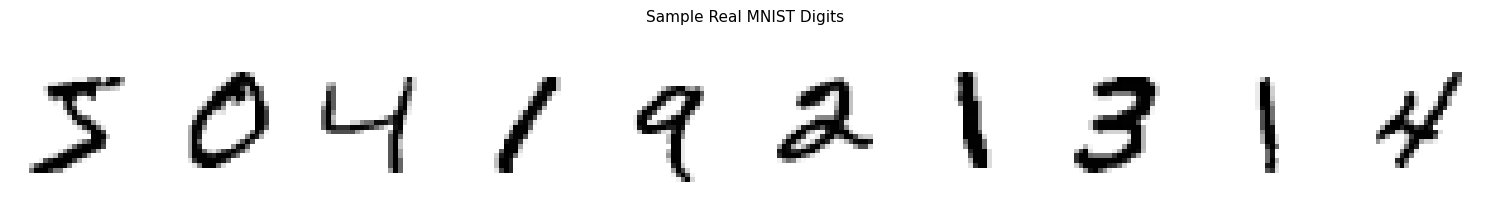

In [3]:
# ── Load & Preprocess MNIST ──────────────────────────────────
(X_train, _), (_, _) = mnist.load_data()

# Normalise to [-1, 1] — matches Generator's tanh output
X_train = X_train.astype('float32') / 127.5 - 1.0
X_train = X_train.reshape(-1, 28, 28, 1)

print(f'Training data shape : {X_train.shape}')
print(f'Pixel range         : [{X_train.min():.2f}, {X_train.max():.2f}]')

# Show sample real digits
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray_r')
    ax.axis('off')
plt.suptitle('Sample Real MNIST Digits', fontsize=11)
plt.tight_layout()
plt.show()

In [4]:
# ── Build Generator ──────────────────────────────────────────
# Maps latent noise z → 28×28 grayscale image
def build_generator(latent_dim):
    model = models.Sequential([
        layers.Dense(7 * 7 * 256, input_dim=latent_dim),
        layers.Reshape((7, 7, 256)),

        # Upsample 7×7 → 14×14
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same'),
        layers.BatchNormalization(momentum=0.8),
        layers.LeakyReLU(alpha=0.2),

        # Upsample 14×14 → 28×28
        layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'),
        layers.BatchNormalization(momentum=0.8),
        layers.LeakyReLU(alpha=0.2),

        layers.Conv2D(32, kernel_size=3, padding='same'),
        layers.BatchNormalization(momentum=0.8),
        layers.LeakyReLU(alpha=0.2),

        # Output layer — tanh maps to [-1, 1]
        layers.Conv2D(1, kernel_size=3, padding='same', activation='tanh')
    ], name='Generator')
    return model

generator = build_generator(LATENT_DIM)
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,266,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,942,145 (7.41 MB)

 Trainable params: 1,941,697 (7.41 MB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
# ── Build Discriminator ──────────────────────────────────────
# Maps 28×28 image → probability of being real
def build_discriminator(img_shape):
    model = models.Sequential([
        layers.Conv2D(64, kernel_size=3, strides=2, padding='same',
                      input_shape=img_shape),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        layers.Conv2D(128, kernel_size=3, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        layers.Conv2D(256, kernel_size=3, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')   # Real=1, Fake=0
    ], name='Discriminator')
    return model

discriminator = build_discriminator(IMG_SHAPE)
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,761 (1.43 MB)

 Trainable params: 373,761 (1.43 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ── Compile Models ───────────────────────────────────────────
# Discriminator: trained independently
discriminator.compile(
    optimizer=optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# GAN (combined): Discriminator is FROZEN when training the Generator
discriminator.trainable = False

gan_input  = layers.Input(shape=(LATENT_DIM,))
fake_image = generator(gan_input)
validity   = discriminator(fake_image)
gan        = models.Model(gan_input, validity, name='GAN')

gan.compile(
    optimizer=optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss='binary_crossentropy'
)

print('GAN architecture ready.')
gan.summary()

GAN architecture ready.


Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Generator (Sequential)          │ (None, 28, 28, 1)      │     1,942,145 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │       373,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,315,906 (8.83 MB)

 Trainable params: 1,941,697 (7.41 MB)

 Non-trainable params: 374,209 (1.43 MB)

In [7]:
# ── Helper: Save Grid of Generated Images ───────────────────
def save_image_grid(epoch, generator, latent_dim, rows=4, cols=8):
    noise      = np.random.normal(0, 1, (rows * cols, latent_dim))
    gen_images = generator.predict(noise, verbose=0)
    gen_images = 0.5 * gen_images + 0.5   # Rescale to [0, 1]

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    for idx, ax in enumerate(axes.flat):
        ax.imshow(gen_images[idx].reshape(28, 28), cmap='gray_r')
        ax.axis('off')
    plt.suptitle(f'Generated Digits — Epoch {epoch}\n'
                 f'Abhishek V Ammanagi | 2023BCSE07AED500', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'exp11_epoch_{epoch:03d}.png', dpi=150)
    plt.show()

print('Helper function defined.')

Helper function defined.


Starting training for 50 epochs...

Epoch    1/50 | D Loss: 0.7096  D Acc: 20.5%  | G Loss: 0.6871
Epoch   10/50 | D Loss: 0.5105  D Acc: 86.9%  | G Loss: 0.5927


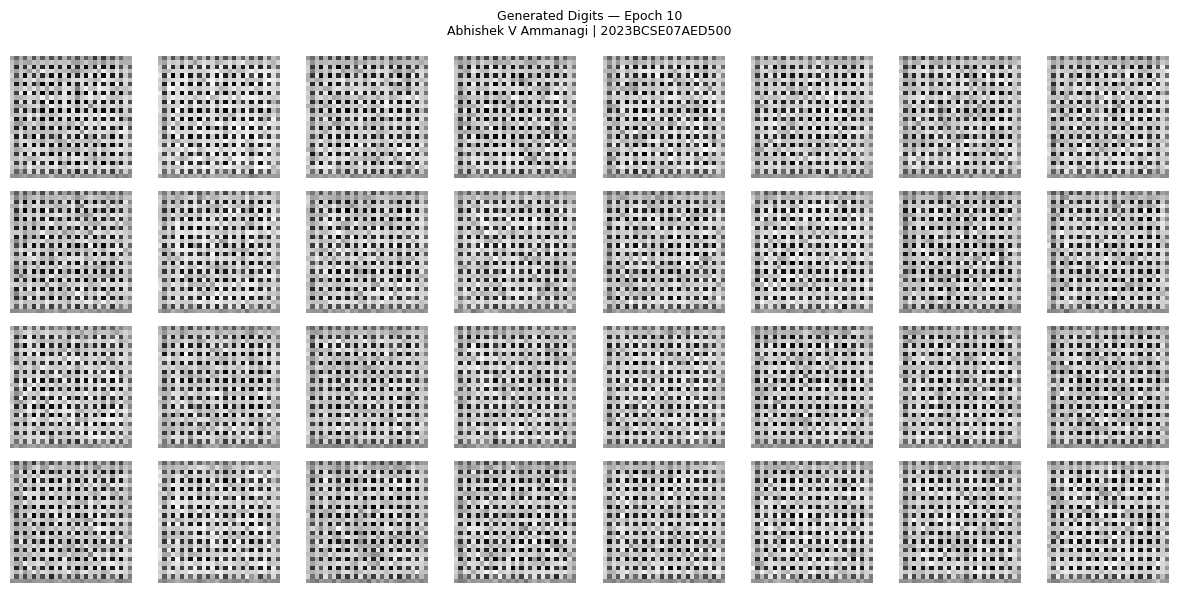

Epoch   20/50 | D Loss: 0.4171  D Acc: 86.0%  | G Loss: 1.2826


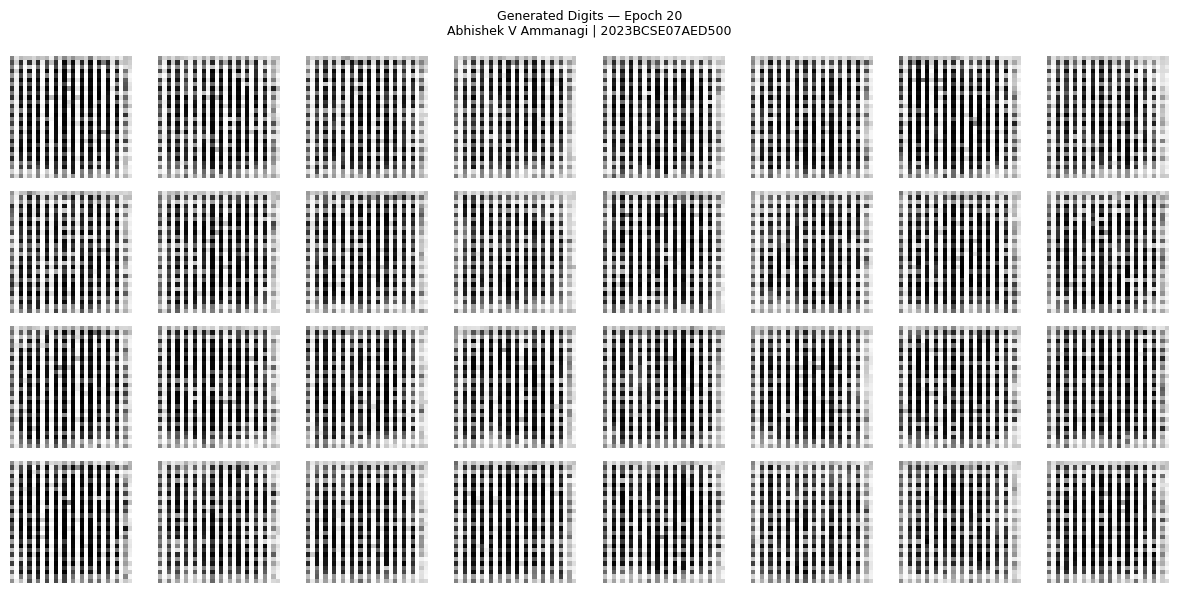

Epoch   30/50 | D Loss: 0.3211  D Acc: 90.0%  | G Loss: 1.6956


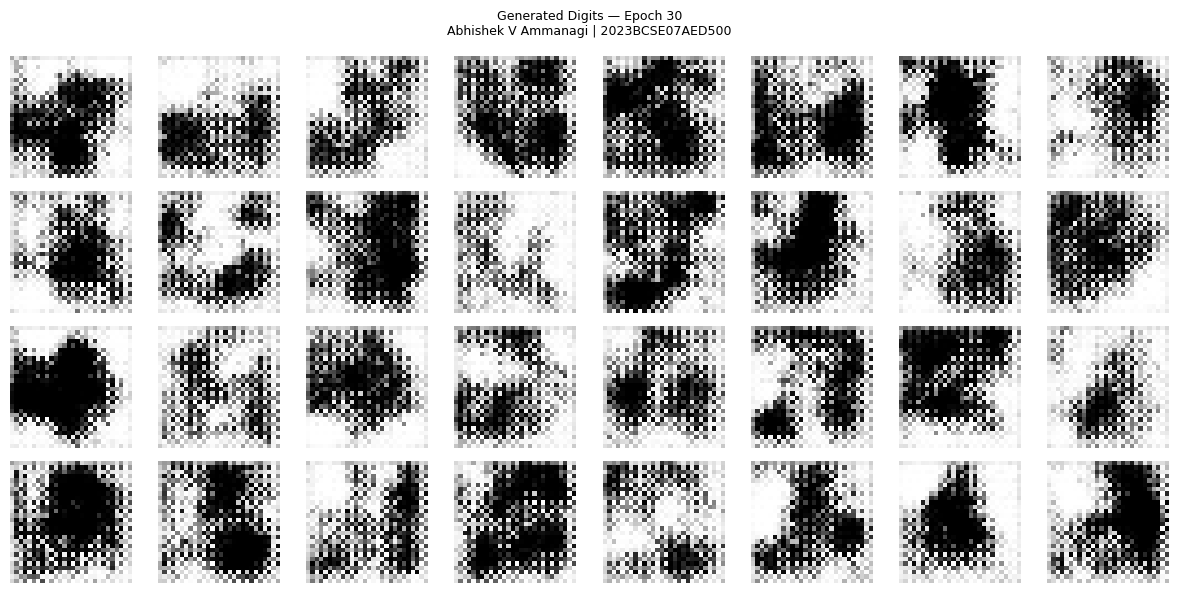

Epoch   40/50 | D Loss: 0.3759  D Acc: 85.7%  | G Loss: 1.6969


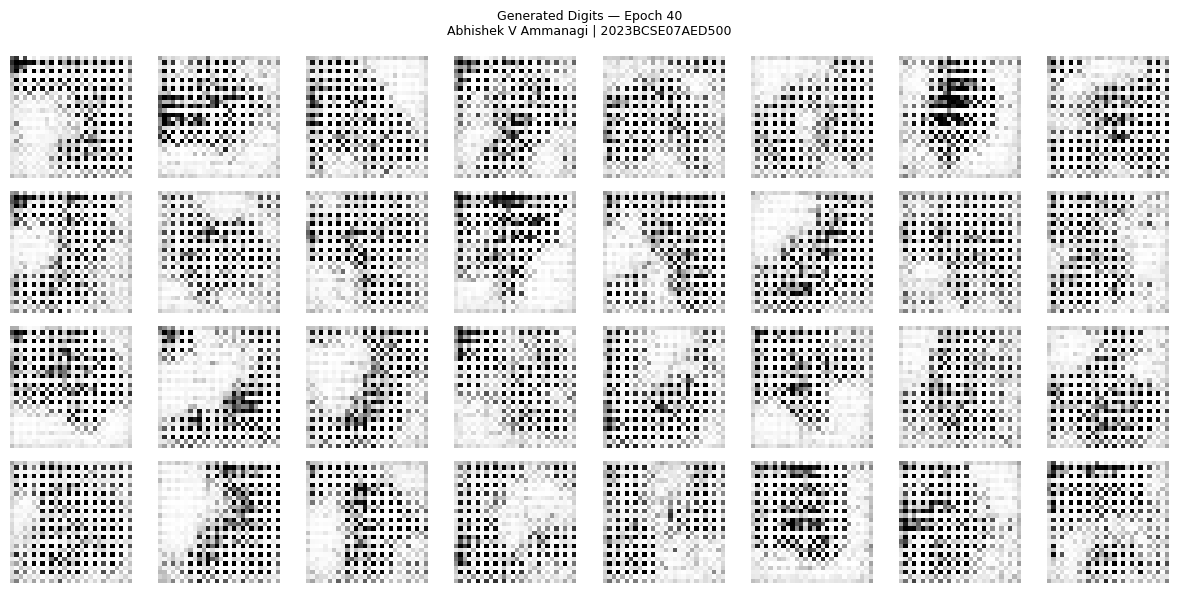

Epoch   50/50 | D Loss: 0.3504  D Acc: 87.9%  | G Loss: 1.6796


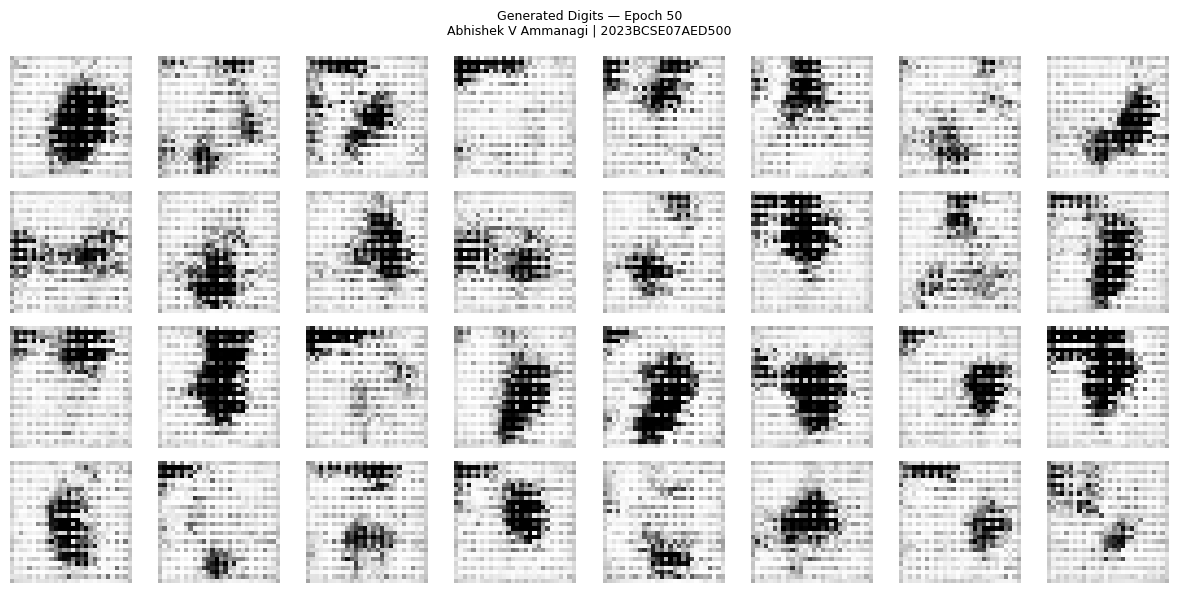


Training complete!


In [8]:
# ── GAN Training Loop ────────────────────────────────────────
d_losses, d_accs = [], []
g_losses         = []

real_labels = np.ones((BATCH_SIZE, 1))   # Label: Real  = 1
fake_labels = np.zeros((BATCH_SIZE, 1))  # Label: Fake  = 0

print(f'Starting training for {EPOCHS} epochs...\n')

for epoch in range(1, EPOCHS + 1):

    # ─── Step 1: Train Discriminator ─────────────────────────
    # Select a random batch of real images
    idx         = np.random.randint(0, X_train.shape[0], BATCH_SIZE)
    real_images = X_train[idx]

    # Generate a batch of fake images
    noise       = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    fake_images = generator.predict(noise, verbose=0)

    # Train on real, then fake
    discriminator.trainable = True
    d_loss_real = discriminator.train_on_batch(real_images, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)
    d_loss      = 0.5 * (d_loss_real[0] + d_loss_fake[0])
    d_acc       = 0.5 * (d_loss_real[1] + d_loss_fake[1])

    # ─── Step 2: Train Generator (via GAN) ───────────────────
    # Generator wants Discriminator to label its output as Real (1)
    discriminator.trainable = False
    noise  = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    g_loss = gan.train_on_batch(noise, real_labels)

    # Log metrics
    d_losses.append(d_loss)
    d_accs.append(d_acc)
    g_losses.append(g_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:>4d}/{EPOCHS} | '
              f'D Loss: {d_loss:.4f}  D Acc: {d_acc*100:.1f}%  | '
              f'G Loss: {g_loss:.4f}')

    if epoch % SAMPLE_INTERVAL == 0:
        save_image_grid(epoch, generator, LATENT_DIM)

print('\nTraining complete!')

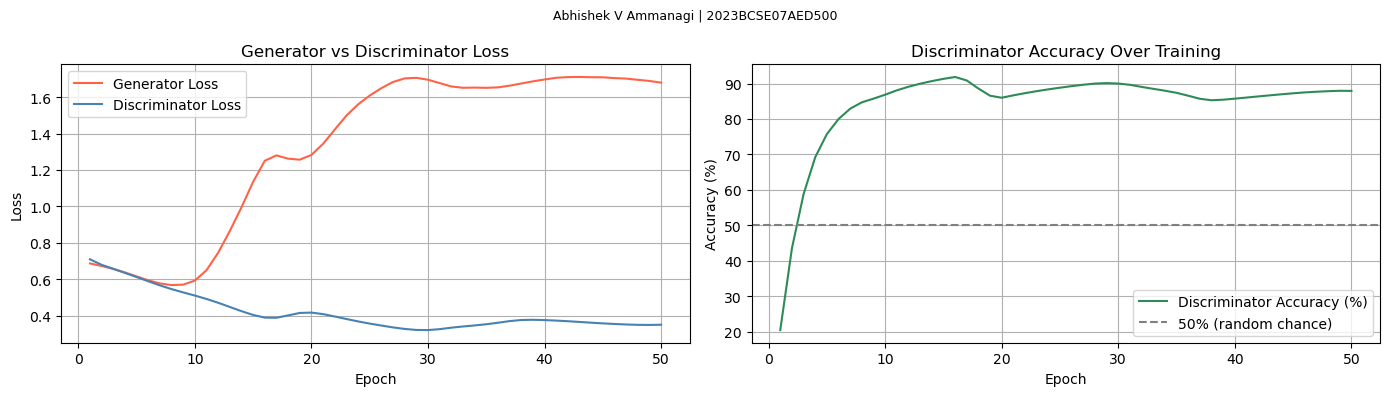

Loss curves saved.


In [9]:
# ── Plot Training Losses & Discriminator Accuracy ────────────
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_range, g_losses, label='Generator Loss',     color='tomato')
axes[0].plot(epochs_range, d_losses, label='Discriminator Loss', color='steelblue')
axes[0].set_title('Generator vs Discriminator Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, [a * 100 for a in d_accs],
             color='seagreen', label='Discriminator Accuracy (%)')
axes[1].axhline(50, color='gray', linestyle='--', label='50% (random chance)')
axes[1].set_title('Discriminator Accuracy Over Training')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Abhishek V Ammanagi | 2023BCSE07AED500', fontsize=9)
plt.tight_layout()
plt.savefig('exp11_losses.png', dpi=200)
plt.show()
print('Loss curves saved.')

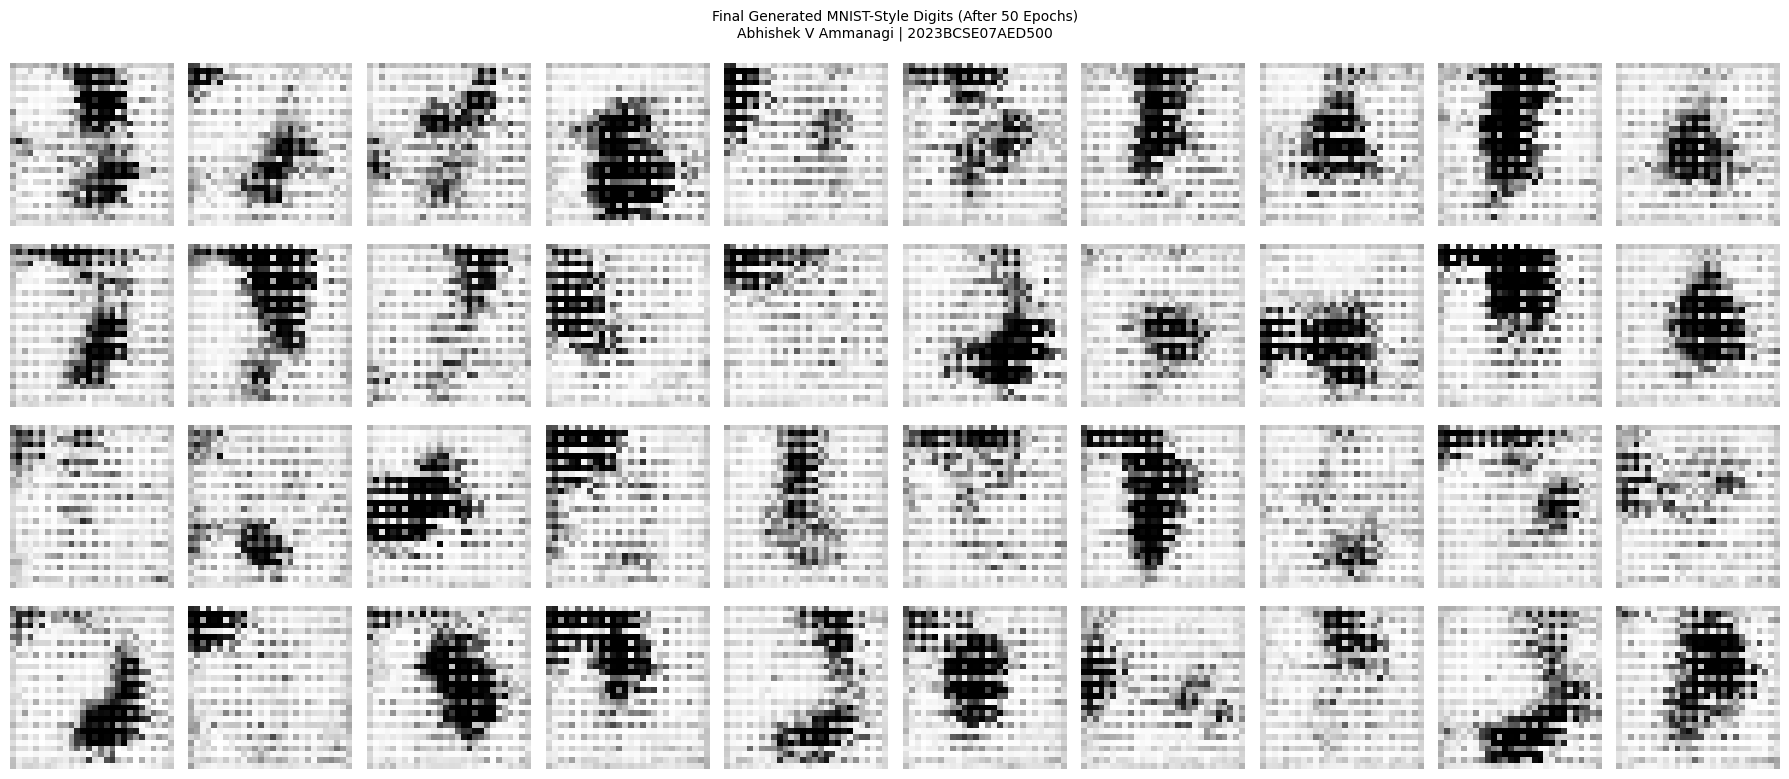

In [10]:
# ── Final Generated Samples ───────────────────────────────────
noise      = np.random.normal(0, 1, (40, LATENT_DIM))
gen_images = generator.predict(noise, verbose=0)
gen_images = 0.5 * gen_images + 0.5

fig, axes = plt.subplots(4, 10, figsize=(18, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(gen_images[i].reshape(28, 28), cmap='gray_r')
    ax.axis('off')
plt.suptitle(f'Final Generated MNIST-Style Digits (After {EPOCHS} Epochs)\n'
             f'Abhishek V Ammanagi | 2023BCSE07AED500', fontsize=10)
plt.tight_layout()
plt.savefig('exp11_final_generated.png', dpi=200)
plt.show()

In [11]:
# ── Analysis Summary ─────────────────────────────────────────
print('=' * 60)
print('  GAN Training Analysis')
print('=' * 60)
print(f'  Final Generator Loss     : {g_losses[-1]:.4f}')
print(f'  Final Discriminator Loss : {d_losses[-1]:.4f}')
print(f'  Final Discriminator Acc  : {d_accs[-1]*100:.1f}%')
print()
print('  Competition Dynamics:')
print('  - Early epochs: D easily distinguishes real vs fake')
print('    → high D accuracy, high G loss')
print('  - Mid epochs  : G starts generating plausible digits')
print('    → D accuracy drops toward 50% (Nash equilibrium)')
print('  - Late epochs : G produces realistic MNIST-style digits')
print('    → Both losses stabilise near equilibrium')
print('=' * 60)
print('Result: GAN successfully generates MNIST-style handwritten')
print('digits through adversarial training.')

  GAN Training Analysis
  Final Generator Loss     : 1.6796
  Final Discriminator Loss : 0.3504
  Final Discriminator Acc  : 87.9%

  Competition Dynamics:
  - Early epochs: D easily distinguishes real vs fake
    → high D accuracy, high G loss
  - Mid epochs  : G starts generating plausible digits
    → D accuracy drops toward 50% (Nash equilibrium)
  - Late epochs : G produces realistic MNIST-style digits
    → Both losses stabilise near equilibrium
Result: GAN successfully generates MNIST-style handwritten
digits through adversarial training.
